In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


In [2]:
# 由于无法上传imdb_processed.csv（分词和清洗后版本的IMDb数据），
# 我们采用datasets库直接加载IMDb原始数据集。
from datasets import load_dataset

# 加载IMDb数据集，包含train和test两个子集，train/test均有25000条影评，每条影评分为正面或负面（0/1）
dataset = load_dataset("imdb")

# 从训练集提取所有文本（影评内容）
# 解释语法:
# 这里，从datasets库加载imdb数据集后，dataset["train"]和dataset["test"]分别是训练集和测试集，
# 每一项为一个字典，包含"text"（评论内容）和"label"（标签：0=负面，1=正面）。
# 使用列表推导式 [item["text"] for item in dataset["train"]] 可以依次取出所有训练集的文本内容。

# datasets 返回的对象不是字典，而是 HuggingFace 提供的 DatasetDict 类型。
# 它的行为和字典类似，可以通过键（如 "train" 或 "test"）获取对应的数据集。
# 但是 dataset["train"] 的类型是 Dataset，它是 datasets 库自定义的数据集对象。
print(type(dataset))              # <class 'datasets.dataset_dict.DatasetDict'>
print(type(dataset["train"]))     # <class 'datasets.arrow_dataset.Dataset'>
print(dataset.keys())             # dict-like, 一般是 dict_keys(['train', 'test'])

train_texts = [item["text"] for item in dataset["train"]]

# 从测试集提取所有文本（影评内容）
test_texts = [item["text"] for item in dataset["test"]]

# 从训练集提取所有的标签（0为负面，1为正面）
train_labels = [item["label"] for item in dataset["train"]]

# 从测试集提取所有的标签（0为负面，1为正面）
test_labels = [item["label"] for item in dataset["test"]]

# 打印训练集和测试集的数量信息，便于确认数据集加载无误
print(f"训练集: {len(train_texts)}条, 测试集: {len(test_texts)}条")

# 将训练集的文本内容全部写入到imdb_train.txt文件，一行一个影评，字符全部转为小写
# 这样能减少后续分词的词表大小（因为大写变小写后"Love"与"love"不会被分为不同的token）
with open("imdb_train.txt", "w", encoding="utf8") as file:  # 保存训练集文本
    for line in train_texts:
        file.write(line.lower() + "\n")  # 写入小写文本，每行对应一个样本

# 将测试集的文本内容全部写入到imdb_test.txt文件，同样转换为小写后写入
with open("imdb_test.txt", "w", encoding="utf8") as file:   # 保存测试集文本
    for line in test_texts:
        file.write(line.lower() + "\n")

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Dataset'>
dict_keys(['train', 'test', 'unsupervised'])
训练集: 25000条, 测试集: 25000条


In [3]:
# 把train_labels和test_labels变为ndarray，然后写入磁盘
train_labels_np = np.array(train_labels)
test_labels_np = np.array(test_labels)
np.save('imdb_train_labels.npy', train_labels_np)
np.save('imdb_test_labels.npy', test_labels_np)


In [4]:
# 从imdb_train_labels.npy和imdb_test_labels.npy读取标签
train_labels = np.load('imdb_train_labels.npy').tolist()
test_labels = np.load('imdb_test_labels.npy').tolist()


In [5]:
sum(train_labels)

12500

In [6]:
sum(test_labels)

12500

In [7]:
with open("imdb_train.txt", "r", encoding="utf8") as f:
    train_texts = [line.strip() for line in f.readlines()]

with open("imdb_test.txt", "r", encoding="utf8") as f:
    test_texts = [line.strip() for line in f.readlines()]


# 准备数据

这里使用subword分词，我们使用已经清洗好的数据集，pip install subword-nmt

In [8]:
# 学习bpe分词(很慢,学一次就好)
!subword-nmt learn-joint-bpe-and-vocab -i ./imdb_train.txt -o ./imdb_bpe_code --write-vocabulary ./imdb_bpe_vocab -s 8000
# -i 选择学习的文件
# -o 核心输出文件,分词需要用到imdb_bpe_code
# --write-vocabulary 字典输出文件
# -s 词表大小

# 应用bpe分词,-c 指定 BPE 编码的配置文件
!subword-nmt apply-bpe -c ./imdb_bpe_code -i ./imdb_train.txt -o ./imdb_train_bpe.txt
!subword-nmt apply-bpe -c ./imdb_bpe_code -i ./imdb_test.txt -o ./imdb_test_bpe.txt


100%|##########| 8000/8000 [00:28<00:00, 278.24it/s]


In [9]:
# 分词后的数据长什么样
!head ./imdb_train_bpe.txt
# @@ 是分词的标记

i rented i am curi@@ ous@@ -@@ yel@@ low from my video store because of all the controver@@ sy that surrounded it when it was first released in 196@@ 7. i also heard that at first it was se@@ i@@ zed by u.s. cu@@ stom@@ s if it ever tried to enter this countr@@ y, therefore being a fan of films considered "@@ controversi@@ al" i really had to see this for my@@ self.<br /><br />the plot is cent@@ ered around a young swe@@ dish drama student named len@@ a who wants to learn everything she can about life. in particular she wants to focus her atten@@ tions to making some sort of documentary on what the average sw@@ ed@@ e thought about certain political issues such as the vietnam war and race issues in the united stat@@ es. in between asking polit@@ ici@@ ans and ordinary den@@ iz@@ ens of sto@@ ck@@ hol@@ m about their opini@@ ons on polit@@ ics, she has sex with her drama teac@@ her, class@@ mat@@ es, and married men@@ .<br /><br />what kills me about i am curi@@ ous@@ -@@ yel@@ low is t

In [10]:
# 初始化一个空列表，用于存储所有分词后的句子（训练集+测试集）
subwords = []

# 读取BPE分词后的训练集文件，每一行为一条评论（分词后的字符串）
with open("imdb_train_bpe.txt", "r", encoding="utf8") as file:
    for line in file.readlines():  # 遍历每一行
        subwords.append(line.strip())  # 去除每行首尾空白符，并添加到subwords列表

# 读取BPE分词后的测试集文件，每一行为一条评论（分词后的字符串）
with open("imdb_test_bpe.txt", "r", encoding="utf8") as file:
    for line in file.readlines():  # 遍历每一行
        subwords.append(line.strip())  # 去除每行首尾空白符，并添加到subwords列表

# 构建一个DataFrame，将所有分词文本、标签和数据来源（train/test）整合在一起
cleaned_df = pd.DataFrame({
    "subwords10k": subwords,  # 子词化后的imdb评论，每行为一个字符串（train+test拼接）
    "label": train_labels + test_labels,  # 标签列表（训练集+测试集顺序拼接）
    "split": ["train"] * len(train_texts) + ["test"] * len(test_texts)  # 记录所属分组，前len(train_texts)个为train，后面为test
})

# 将上述DataFrame保存为CSV文件，后续加载时可直接引用，无需重复分词
cleaned_df.to_csv("imdb_subwords.csv", index=False)  # index=False避免写入行号

In [11]:
cleaned_df.head()

,subwords10k,label,split
0,i rented i am curi@@ ous@@ -@@ yel@@ low from ...,0,train
1,"""i am curi@@ ous@@ : yel@@ low@@ "" is a ri@@ s...",0,train
2,if only to avoid making this type of film in t...,0,train
3,this film was probably inspired by go@@ dar@@ ...,0,train
4,"oh, brother@@ ...@@ after hearing about this r...",0,train


In [12]:
cleaned_df.shape

(50000, 3)

In [13]:
from torch.utils.data import Dataset, DataLoader

# 定义IMDB数据集类，继承自torch.utils.data.Dataset
# 这个类的作用是将IMDB的BPE分词数据包装为可直接用于PyTorch的Dataset对象
class IMDBDataset(Dataset):
    def __init__(self, mode="train"):
        """
        初始化IMDBDataset对象。

        参数:
            mode (str): 指定加载哪一部分数据，"train"为训练集，"test"为测试集。

        功能说明:
            - 从保存有分词数据和标签的CSV文件("imdb_subwords.csv")中加载数据
            - 该CSV文件包含三列:
                1. subwords10k: 分词后的文本，字符串形式，每个分词之间用空格分隔
                2. label: 标签，0/1表示负面/正面
                3. split: 数据划分，取值为"train"或"test"
            - 根据传入的mode参数，利用Pandas的query按split筛选出对应的数据子集
            - 分别将分词文本和标签存入self.texts和self.labels这两个实例变量中
        """
        # 读取CSV文件并根据split筛选数据行（mode可以为'train'或'test'）
        df = pd.read_csv("imdb_subwords.csv").query("split == '{}'".format(mode))
        # 提取所有分词文本（字符串形式，后续需split转为子词列表）
        self.texts = df["subwords10k"].values
        # 提取所有标签（np.array或list格式）
        self.labels = df["label"].values

    def __len__(self):
        """
        返回数据集中样本的总数。

        用于PyTorch DataLoader自动获取数据集大小。

        返回:
            int: 当前数据集中的样本数量
        """
        return len(self.labels)

    def __getitem__(self, idx):
        """
        通过下标idx获取单个样本数据，供DataLoader迭代使用。

        参数:
            idx (int): 指定要获取的样本索引

        返回:
            tuple: (子词列表, 标签)
                - 子词列表: 对应idx位置的文本字符串按空格split拆分成一个子词列表
                - 标签: int类型的正负面标签
        """
        # self.texts[idx]是分词文本（空格分隔的字符串），用split方法转为list
        # self.labels[idx]是整数标签
        return self.texts[idx].split(), self.labels[idx]

# 创建IMDB数据集的训练集和测试集对象
# 这两个对象可直接输入给PyTorch DataLoader进行批量加载及后续深度学习处理
train_ds = IMDBDataset("train")  # 构造训练集对象
test_ds = IMDBDataset("test")    # 构造测试集对象

In [14]:
train_ds[0]

(['i',
  'rented',
  'i',
  'am',
  'curi@@',
  'ous@@',
  '-@@',
  'yel@@',
  'low',
  'from',
  'my',
  'video',
  'store',
  'because',
  'of',
  'all',
  'the',
  'controver@@',
  'sy',
  'that',
  'surrounded',
  'it',
  'when',
  'it',
  'was',
  'first',
  'released',
  'in',
  '196@@',
  '7.',
  'i',
  'also',
  'heard',
  'that',
  'at',
  'first',
  'it',
  'was',
  'se@@',
  'i@@',
  'zed',
  'by',
  'u.s.',
  'cu@@',
  'stom@@',
  's',
  'if',
  'it',
  'ever',
  'tried',
  'to',
  'enter',
  'this',
  'countr@@',
  'y,',
  'therefore',
  'being',
  'a',
  'fan',
  'of',
  'films',
  'considered',
  '"@@',
  'controversi@@',
  'al"',
  'i',
  'really',
  'had',
  'to',
  'see',
  'this',
  'for',
  'my@@',
  'self.<br',
  '/><br',
  '/>the',
  'plot',
  'is',
  'cent@@',
  'ered',
  'around',
  'a',
  'young',
  'swe@@',
  'dish',
  'drama',
  'student',
  'named',
  'len@@',
  'a',
  'who',
  'wants',
  'to',
  'learn',
  'everything',
  'she',
  'can',
  'about',
  'life.

In [15]:
train_ds[0][0]

['i',
 'rented',
 'i',
 'am',
 'curi@@',
 'ous@@',
 '-@@',
 'yel@@',
 'low',
 'from',
 'my',
 'video',
 'store',
 'because',
 'of',
 'all',
 'the',
 'controver@@',
 'sy',
 'that',
 'surrounded',
 'it',
 'when',
 'it',
 'was',
 'first',
 'released',
 'in',
 '196@@',
 '7.',
 'i',
 'also',
 'heard',
 'that',
 'at',
 'first',
 'it',
 'was',
 'se@@',
 'i@@',
 'zed',
 'by',
 'u.s.',
 'cu@@',
 'stom@@',
 's',
 'if',
 'it',
 'ever',
 'tried',
 'to',
 'enter',
 'this',
 'countr@@',
 'y,',
 'therefore',
 'being',
 'a',
 'fan',
 'of',
 'films',
 'considered',
 '"@@',
 'controversi@@',
 'al"',
 'i',
 'really',
 'had',
 'to',
 'see',
 'this',
 'for',
 'my@@',
 'self.<br',
 '/><br',
 '/>the',
 'plot',
 'is',
 'cent@@',
 'ered',
 'around',
 'a',
 'young',
 'swe@@',
 'dish',
 'drama',
 'student',
 'named',
 'len@@',
 'a',
 'who',
 'wants',
 'to',
 'learn',
 'everything',
 'she',
 'can',
 'about',
 'life.',
 'in',
 'particular',
 'she',
 'wants',
 'to',
 'focus',
 'her',
 'atten@@',
 'tions',
 'to',
 '

In [16]:
train_ds[0][1]

np.int64(0)

## 构造 word2idx 和 idx2word

In [ ]:
# # 载入子词词表，并构建 word2idx（词到索引的映射）和 idx2word（索引到词的映射），并查看词表长度
# # 词表就像为后续子词编码提供“翻译本”的英语字典

# # 首先定义4个特殊token的映射（需要在所有样本开头/结尾/pad/未知情况下用到）
# word2idx = {
#     "[PAD]": 0,     # 填充token，在句子不够max_length时用于补齐
#     "[BOS]": 1,     # 句子开始符号 (begin of sentence)
#     "[UNK]": 2,     # 未知token，处理词表外的新词
#     "[EOS]": 3,     # 句子结束符号 (end of sentence)
# }
# # 索引到token的反向映射
# idx2word = {value: key for key, value in word2idx.items()}

# print(idx2word)  # 打印特殊token的映射，检查初始化是否正确

# index = len(idx2word)   # 当前词表已有的token数量，这里为4, 后面新词从index开始编号
# threshold = 1           # 只保留出现次数大于等于threshold的token（低频词会被舍弃）

# # 打开 BPE 子词词表文件，每一行为“token 词频”，如"the 322766"
# with open("imdb_bpe_vocab", "r", encoding="utf8") as file:
#     for line in tqdm(file.readlines()):             # tqdm用于显示读取进度条
#         temp = line.strip().split()                 # 去首尾空白，按空格切分为[token, counts]
#         if len(temp) != 2:
#             # 发现异常行时打印并跳过（有的行格式不对）
#             print(temp)
#             continue
#         token, counts = temp                        # token: 子词字符串；counts: 出现频次
#         if int(counts) >= threshold:                # 只加入高于阈值的词
#             word2idx[token] = index                 # 新token写入word2idx，值为当前index
#             idx2word[index] = token                 # 写入idx2word，键为index值为token
#             index += 1                             # index自增，为下一个token分配新id

# vocab_size = len(word2idx)                          # 词表总长度（含4个特殊符号）
# print("vocab_size: {}".format(vocab_size))          # 打印最终词表大小

# 载入BPE子词词表，并构建 word2idx 和 idx2word 字典，词表相当于英语的单词字典
word2idx = {
    "[PAD]": 0,     # 填充 token（用于补齐不同长度的序列，保持张量维度一致）
    "[BOS]": 1,     # 句子起始符号 (begin of sentence)
    "[UNK]": 2,     # 未知token（OOV词、未登录词，遇到没见过的字词统一映射为此）
    "[EOS]": 3,     # 句子结束符号 (end of sentence)
}
index = len(word2idx)  # 当前词表已有的token数量（特殊token共4个），后续新词从index开始编号
threshold = 1  # 出现次数低于此阈值的token将被舍弃，仅保留高频token

# 逐行读取BPE词表文件“imdb_bpe_vocab”，每一行保存一个token及其出现次数
with open("imdb_bpe_vocab", "r", encoding="utf8") as file:
    for line in file.readlines():
        temp = line.strip().split()  # 去除首尾空白，并根据空格切分为[token, counts]
        if len(temp) != 2:
            # 遇到格式错误的行进行提示输出（例如某些异常文本行），便于定位数据异常
            print(temp) 
        else:
            token, counts = temp
            if int(counts) >= threshold:  # 只保留频次大于等于阈值的token
                if token not in word2idx:  # 如果该token已在特殊token中出现，则跳过
                    word2idx[token] = index  # 为新token分配index，并写入word2idx映射表
                    index += 1               # index自增，为下一个新词分配新编号

# 统计最终词表大小，包括4个特殊token与所有高频token
vocab_size = len(word2idx)
print("vocab_size: {}".format(vocab_size))  # 打印词表长度，便于查看BPE分词的容量

# 构建 idx2word 字典：用于根据 token下标快速反查原始token字符串
idx2word = {idx: word for word, idx in word2idx.items()}


['707']
['2']
vocab_size: 8230


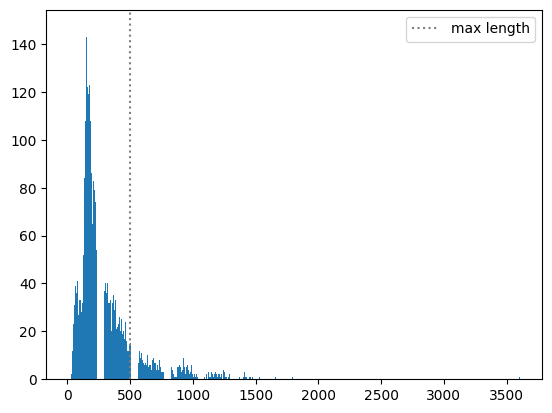

In [19]:
# 选择 max_length
length_collect = {}
for text, label in train_ds:
    length = len(text)
    length_collect[length] = length_collect.get(length, 0) + 1
    
MAX_LENGTH = 500
plt.bar(length_collect.keys(), length_collect.values())
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
plt.legend()
plt.show()

## Tokenizer

In [20]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        BPE分词器Tokenizer
        Args:
            word2idx: 词到序号的映射字典（token2id）
            idx2word: 序号到词的映射字典（id2token）
            max_length: 最大序列长度（默认500）
            pad_idx: PAD符号的索引，默认为0
            bos_idx: BOS符号（句首）的索引，默认为1
            eos_idx: EOS符号（句尾）的索引，默认为3
            unk_idx: 未登录词（未OOV）的索引，默认为2
        """
        self.word2idx = word2idx    # token到下标的映射
        self.idx2word = idx2word    # 下标到token的映射
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx
    
    def encode(self, text_list, padding_first=False):
        """
        将输入的分词文本列表编码为索引张量，并做padding
        
        Args:
            text_list: list，每个元素是字符串的list（已切好subword），如[['i', 'am'], ['he', 'is']...]
            padding_first: bool，是否在前面补padding（True表示左侧补pad；False表示右侧padding）
            
        Returns:
            shape = [batch_size, max_length] 的Long tensor
        """
        # 针对当前batch, 计算本batch中的max length, 取最大不能超过self.max_length。2是BOS/EOS
        max_length = min(self.max_length, 2 + max([len(text) for text in text_list]))
        indices_list = []
        for text in text_list:
            # 句子转为token索引。句首加BOS，句尾加EOS。词不在词表则用UNK
            indices = [self.bos_idx] + \
                      [self.word2idx.get(word, self.unk_idx) for word in text[:max_length-2]] + \
                      [self.eos_idx]
            # 补齐到max_length，左/右侧补pad
            if padding_first:
                # 前面补pad
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # 后面补pad
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        # 转为torch张量
        return torch.tensor(indices_list)
    
    
    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        反编码，将token索引转换回token字符串
        Args:
            indices_list: 输入为list of list，每个内部list是一句话的token indices
            remove_bos: 是否去掉BOS
            remove_eos: 是否遇到EOS时就截断
            remove_pad: 是否遇到PAD时就截断
            split: 是否以list形式返回（否则是用空格join后的字符串）
        Returns:
            list，每个元素为str或list[str]
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]")   # 如果索引不在idx2word字典则返回UNK
                if remove_bos and word == "[BOS]":
                    continue
                # 如果遇到EOS并设置删除，则直接break，后续内容全部忽略
                if remove_eos and word == "[EOS]":
                    break
                # 如果遇到PAD并设置删除，则直接break，后续内容全部忽略
                if remove_pad and word == "[PAD]":
                    break
                text.append(word)
            # 是否返回拼接字符串
            text_list.append(" ".join(text) if not split else text)
        return text_list
    

# 创建Tokenizer实例
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)
# 取训练集前两条数据测试分词器
raw_text = [train_ds[0][0], train_ds[1][0]]
# 将分词后的文本编码成token indices
indices = tokenizer.encode(raw_text, padding_first=False)
# 解码回token列表
decode_text = tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)
print("raw text")
for raw in raw_text:
    print(raw)
print("indices")
for index in indices:
    print(index)
print("decode text")
for decode in decode_text:
    print(decode)

raw text
['i', 'rented', 'i', 'am', 'curi@@', 'ous@@', '-@@', 'yel@@', 'low', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controver@@', 'sy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '196@@', '7.', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'se@@', 'i@@', 'zed', 'by', 'u.s.', 'cu@@', 'stom@@', 's', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'countr@@', 'y,', 'therefore', 'being', 'a', 'fan', 'of', 'films', 'considered', '"@@', 'controversi@@', 'al"', 'i', 'really', 'had', 'to', 'see', 'this', 'for', 'my@@', 'self.<br', '/><br', '/>the', 'plot', 'is', 'cent@@', 'ered', 'around', 'a', 'young', 'swe@@', 'dish', 'drama', 'student', 'named', 'len@@', 'a', 'who', 'wants', 'to', 'learn', 'everything', 'she', 'can', 'about', 'life.', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her', 'atten@@', 'tions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average', 'sw@@', 'ed@@', 'e', '

In [21]:
def collate_fct(batch):
    """
    把字符串列表转化为tensor
    :param batch:
    :return:
    """
    text_list = [item[0] for item in batch] #batch中每个item的第一个元素是text,是输入，类型为list
    label_list = [item[1] for item in batch] #batch中每个item的第二个元素是label,是输出，类型为int
    # 这里使用 padding first
    text_list = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)
    return text_list, torch.tensor(label_list).reshape(-1, 1).to(dtype=torch.float)

batch_size = 128
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fct)

# 定义模型

In [22]:
class LSTM(nn.Module):
    def __init__(self, embedding_dim=16, hidden_dim=64, vocab_size=vocab_size, num_layers=1, bidirectional=False):
        super(LSTM, self).__init__()
        self.embeding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)
        self.layer = nn.Linear(hidden_dim * (2 if bidirectional else 1), hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # [bs, seq length]
        x = self.embeding(x)
        # [bs, seq length, embedding_dim] -> shape [bs, embedding_dim, seq length]
        seq_output, (hidden, cell) = self.lstm(x)
        # [bs, seq length, hidden_dim], [*, bs, hidden_dim]
        x = seq_output[:, -1, :]
        # 取最后一个时间步的输出 (这也是为什么要设置padding_first=True的原因)
        x = self.layer(x)
        x = self.fc(x)
        return x
    
sample_inputs = torch.randint(0, vocab_size, (2, 128))
    
print("{:=^80}".format(" 一层单向 LSTM "))       
for key, value in LSTM().named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

    
print("{:=^80}".format(" 一层双向 LSTM "))       
for key, value in LSTM(bidirectional=True).named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

    
print("{:=^80}".format(" 两层单向 LSTM "))       
for key, value in LSTM(num_layers=2).named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")


================================== 一层单向 LSTM ===================================
            embeding.weight             paramerters num: 131680
           lstm.weight_ih_l0            paramerters num: 4096
           lstm.weight_hh_l0            paramerters num: 16384
            lstm.bias_ih_l0             paramerters num: 256
            lstm.bias_hh_l0             paramerters num: 256
              layer.weight              paramerters num: 4096
               layer.bias               paramerters num: 64
               fc.weight                paramerters num: 64
                fc.bias                 paramerters num: 1
================================== 一层双向 LSTM ===================================
            embeding.weight             paramerters num: 131680
           lstm.weight_ih_l0            paramerters num: 4096
           lstm.weight_hh_l0            paramerters num: 16384
            lstm.bias_ih_l0             paramerters num: 256
            lstm.bias_hh_l0         

# 训练

In [23]:
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    pred_list = []
    label_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas)
        loss = loss_fct(logits, labels)         # 验证集损失
        loss_list.append(loss.item())
        # 二分类
        preds = logits > 0
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())
        
    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc


### Save Best


In [24]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = -1
        
        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return
        
        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



### Early Stop

In [25]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.counter = 0
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter 
            self.counter = 0
        else: 
            self.counter += 1
            
    @property
    def early_stop(self):
        return self.counter >= self.patience


In [26]:
# 训练
def training(
    model, 
    train_loader, 
    val_loader, 
    epoch, 
    loss_fct, 
    optimizer, 
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 模型前向计算
                logits = model(datas)
                # 计算损失
                loss = loss_fct(logits, labels)
                # 梯度回传
                loss.backward()
                # 调整优化器，包括学习率的变动等
                optimizer.step()
                preds = logits > 0
            
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())    
                loss = loss.cpu().item()
                # record
                
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })
                
                # evaluating
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()
                    
                    # 1. 使用 tensorboard 可视化
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step, 
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],
                            )
                
                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict
                    
                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})
        
    return record_dict
        

epoch = 20

model = LSTM()

# 1. 定义损失函数 采用交叉熵损失 (但是二分类)
loss_fct = F.binary_cross_entropy_with_logits
# 2. 定义优化器 采用 adam
# Optimizers specified in the torch.optim package
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 1. tensorboard 可视化
if not os.path.exists("runs"):
    os.mkdir("runs")


# 2. save best
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback("checkpoints/imdb-lstm-subword", save_step=len(train_dl), save_best_only=True)
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)
record = training(
    model, 
    train_dl, 
    test_dl, 
    epoch, 
    loss_fct, 
    optimizer, 
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_dl)
    )

  0%|          | 0/3920 [00:00<?, ?it/s]

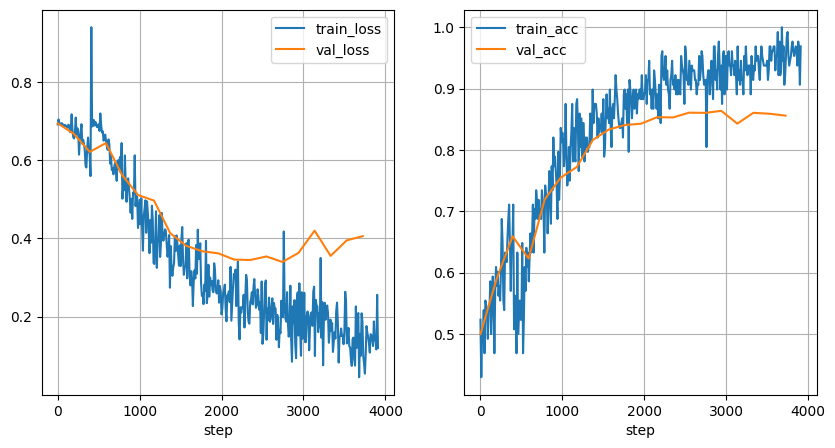

In [29]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):    
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        # axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        axs[idx].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record, sample_step=10)  #横坐标是 steps

# 评估

In [30]:
# dataload for evaluating

# load checkpoints
model.load_state_dict(torch.load("checkpoints/imdb-lstm-subword/best.ckpt", map_location="cpu"))

model.eval()
loss, acc = evaluating(model, test_dl, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.3631
accuracy: 0.8637
